# 1D Cross-Section Levee Authoring

Read, modify, insert, and remove cross-section levee station-elevation data
in a real HEC-RAS geometry file, then run the unsteady simulation on the
modified geometry and verify results extraction from the HDF output.

**Example Project:** Bald Eagle Creek (1D Unsteady Flow Hydraulics)

## Overview

HEC-RAS 1D cross sections can have left and/or right levee points defined as station-elevation pairs. These control when water overtops the levee and enters the floodplain.

**Storage format:** Each cross section's levee data is stored on a single `Levee=` line in the `.g##` text file:
```
Levee=left_flag,left_station,left_elevation,right_flag,right_station,right_elevation,0,0
```
- Active sides use flag `-1` with station and elevation values
- Inactive sides use flag `0` with blank station/elevation fields

**Blank vs. explicit elevation - two distinct behaviors:**

| Elevation field | Solver overtopping threshold | RASMapper flood polygon clipping |
|----------------|------------------------------|----------------------------------|
| **Blank** (NaN) | Ground elevation at levee station, interpolated from XS profile | Inactive -- HDF Levees dataset not written |
| **Explicit** (e.g., 544.39 ft) | Defined crest elevation | Active -- HDF Levees dataset written, polygon boundary clipped |

> **Note:** Never write `0.0` when you mean "no elevation defined." Zero is a valid elevation and will be treated as an explicit 0 ft crest -- use NaN to produce a blank field. In Bald Eagle Creek, 40 of 41 active levees have blank elevation -- the standard pattern for 1D models where the ground profile serves as the levee crest.

**API methods:**
- `get_levees()` — Read all levee data as a DataFrame
- `set_levees()` — Write levee data for a single cross section (update or insert)

## 1. Setup and Imports

In [1]:
# =============================================================================
# DEVELOPMENT MODE TOGGLE
# =============================================================================
USE_LOCAL_SOURCE = False

if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path

    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: loading from {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE: loading installed ras-commander")

from pathlib import Path
import logging
import os
import re
import warnings

import pandas as pd
import numpy as np
import shutil

from IPython.display import display

from ras_commander import RasExamples
from ras_commander.geom.GeomCrossSection import GeomCrossSection

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

import ras_commander

print(f"Loaded: {ras_commander.__file__}")

PIP PACKAGE MODE: loading installed ras-commander


Loaded: G:\GH\ras-commander\ras_commander\__init__.py


## 2. Extract Example Project

In [2]:
project_path = RasExamples.extract_project("Balde Eagle Creek")
geom_file = project_path / "BaldEagle.g01"

print(f"Project: {project_path}")
print(f"Geometry file exists: {geom_file.exists()}")

Project: G:\GH\ras-commander\working\notebook_runs\20260518_185328_217_levee\example_projects\Balde Eagle Creek
Geometry file exists: True


## 3. Read All Levees

`get_levees()` returns a DataFrame with columns: `xs_id`, `River`, `Reach`, `RS`, `left_station`, `left_elevation`, `right_station`, `right_elevation`. Cross sections without levees have NaN values.

In [3]:
all_levees = GeomCrossSection.get_levees(geom_file)

total_xs = len(all_levees)
has_left = all_levees["left_station"].notna().sum()
has_right = all_levees["right_station"].notna().sum()
has_both = (all_levees["left_station"].notna() & all_levees["right_station"].notna()).sum()
has_none = (all_levees["left_station"].isna() & all_levees["right_station"].isna()).sum()

print(f"Total cross sections: {total_xs}")
print(f"  With left levee:  {has_left}")
print(f"  With right levee: {has_right}")
print(f"  With both sides:  {has_both}")
print(f"  With no levees:   {has_none}")
print(f"\nColumns: {list(all_levees.columns)}")
print(f"\nFirst 15 rows:")
all_levees.head(15)

Total cross sections: 189
  With left levee:  28
  With right levee: 18
  With both sides:  5
  With no levees:   148

Columns: ['xs_id', 'River', 'Reach', 'RS', 'left_station', 'left_elevation', 'right_station', 'right_elevation']

First 15 rows:


,xs_id,River,Reach,RS,left_station,left_elevation,right_station,right_elevation
0,Bald Eagle|Loc Hav|138154.4,Bald Eagle,Loc Hav,138154.4,NaN,NaN,NaN,NaN
1,Bald Eagle|Loc Hav|137690.8,Bald Eagle,Loc Hav,137690.8,NaN,NaN,NaN,NaN
2,Bald Eagle|Loc Hav|137327.0,Bald Eagle,Loc Hav,137327.0,NaN,NaN,NaN,NaN
3,Bald Eagle|Loc Hav|136564.9,Bald Eagle,Loc Hav,136564.9,NaN,NaN,NaN,NaN
4,Bald Eagle|Loc Hav|136202.3,Bald Eagle,Loc Hav,136202.3,NaN,NaN,NaN,NaN
5,Bald Eagle|Loc Hav|135591.4,Bald Eagle,Loc Hav,135591.4,NaN,NaN,574.99,NaN
6,Bald Eagle|Loc Hav|135068.7,Bald Eagle,Loc Hav,135068.7,NaN,NaN,NaN,NaN
7,Bald Eagle|Loc Hav|134487.2,Bald Eagle,Loc Hav,134487.2,NaN,NaN,NaN,NaN
8,Bald Eagle|Loc Hav|133881.0,Bald Eagle,Loc Hav,133881.0,NaN,NaN,NaN,NaN
9,Bald Eagle|Loc Hav|133446.1,Bald Eagle,Loc Hav,133446.1,NaN,NaN,NaN,NaN


## 4. Filter by River/Reach/RS

Use optional `river`, `reach`, and `rs` parameters to narrow the query.

In [4]:
river_name = all_levees["River"].iloc[0]
reach_name = all_levees["Reach"].iloc[0]

print(f"River: {river_name}, Reach: {reach_name}")

# Filter to just cross sections with active levees
active_levees = all_levees[
    all_levees["left_station"].notna() | all_levees["right_station"].notna()
].copy()

print(f"\nActive levee cross sections ({len(active_levees)} of {total_xs}):")
active_levees[["xs_id", "left_station", "left_elevation", "right_station", "right_elevation"]]

River: Bald Eagle, Reach: Loc Hav

Active levee cross sections (41 of 189):


,xs_id,left_station,left_elevation,right_station,right_elevation
5,Bald Eagle|Loc Hav|135591.4,NaN,NaN,574.99,NaN
10,Bald Eagle|Loc Hav|132973.6,80.0,NaN,NaN,NaN
14,Bald Eagle|Loc Hav|130339.2,100.0,NaN,NaN,NaN
18,Bald Eagle|Loc Hav|127410.9,NaN,NaN,2349.99,NaN
19,Bald Eagle|Loc Hav|126741.0,NaN,NaN,1935.00,NaN
52,Bald Eagle|Loc Hav|104647.2,NaN,NaN,3488.00,NaN
53,Bald Eagle|Loc Hav|104195.0,NaN,NaN,3068.00,NaN
54,Bald Eagle|Loc Hav|103854.0,NaN,NaN,3285.00,NaN
55,Bald Eagle|Loc Hav|103369.7,205.0,NaN,3615.00,NaN
57,Bald Eagle|Loc Hav|103122.3,135.0,NaN,3630.00,NaN


In [5]:
# Read a single cross section by xs_id
target_xs = active_levees["xs_id"].iloc[0]
single = GeomCrossSection.get_levees(geom_file, xs_id=target_xs)

print(f"Single cross section: {target_xs}")
single

Single cross section: Bald Eagle|Loc Hav|135591.4


,xs_id,River,Reach,RS,left_station,left_elevation,right_station,right_elevation
0,Bald Eagle|Loc Hav|135591.4,Bald Eagle,Loc Hav,135591.4,NaN,NaN,574.99,NaN


## 5. Update Existing Levees (Round-Trip)

`set_levees()` updates the `Levee=` line for a specific cross section. A levee point has two independent properties:
- **Station** — horizontal position in the cross section (ft from the left edge)
- **Elevation** — overtopping elevation (ft NAVD88); if not set (NaN), HEC-RAS uses the ground elevation at the levee station

We demonstrate three round-trip operations:
- **5a. Move station** — shift the left levee outward +10 ft
- **5b. Raise elevation** — increase the right levee crest by +2 ft (RS 7936.130, the only cross section in this project with a defined levee elevation)
- **5c. Lower elevation** — lower the right levee crest by −2 ft from original

In [6]:
# Create a working copy
work_copy = project_path / "BaldEagle_levee_test.g01"
shutil.copy(geom_file, work_copy)
print(f"Working copy: {work_copy.name}")

# ── 5a. Move levee station ──────────────────────────────────────────────────
both_sides = active_levees[
    active_levees["left_station"].notna() & active_levees["right_station"].notna()
]
target_sta = both_sides["xs_id"].iloc[0]
orig_sta = GeomCrossSection.get_levees(work_copy, xs_id=target_sta)

new_left = orig_sta["left_station"].iloc[0] + 10.0
GeomCrossSection.set_levees(
    work_copy, xs_id=target_sta,
    left_station=new_left,
    right_station=orig_sta["right_station"].iloc[0],
    create_backup=False,
)
after_sta = GeomCrossSection.get_levees(work_copy, xs_id=target_sta)
assert np.isclose(after_sta["left_station"].iloc[0], new_left)
print(f"5a. Station moved:    {target_sta}")
print(f"    Left: {orig_sta['left_station'].iloc[0]:.1f} → {after_sta['left_station'].iloc[0]:.1f} ft  (+10 ft)")

# ── 5b. Raise levee elevation ───────────────────────────────────────────────
# RS 7936.130 has the only real right_elevation in this project (544.39 ft)
elev_xs_id = "Bald Eagle|Loc Hav|7936.130"
orig_elev_row   = GeomCrossSection.get_levees(work_copy, xs_id=elev_xs_id)
orig_left_sta   = orig_elev_row["left_station"].iloc[0]    # 145.0
orig_right_sta  = orig_elev_row["right_station"].iloc[0]   # 1240.02
orig_right_elev = orig_elev_row["right_elevation"].iloc[0] # 544.39
raised_elev = orig_right_elev + 2.0  # 546.39

GeomCrossSection.set_levees(
    work_copy, xs_id=elev_xs_id,
    left_station=orig_left_sta,
    right_station=orig_right_sta,
    right_elevation=raised_elev,
    create_backup=False,
)
after_raise = GeomCrossSection.get_levees(work_copy, xs_id=elev_xs_id)
assert np.isclose(after_raise["right_elevation"].iloc[0], raised_elev)
print(f"\n5b. Elevation raised: {elev_xs_id}")
print(f"    Right elev: {orig_right_elev:.2f} → {after_raise['right_elevation'].iloc[0]:.2f} ft  (+2.00 ft)")

# ── 5c. Lower levee elevation ───────────────────────────────────────────────
lowered_elev = orig_right_elev - 2.0  # 542.39

GeomCrossSection.set_levees(
    work_copy, xs_id=elev_xs_id,
    left_station=orig_left_sta,
    right_station=orig_right_sta,
    right_elevation=lowered_elev,
    create_backup=False,
)
after_lower = GeomCrossSection.get_levees(work_copy, xs_id=elev_xs_id)
assert np.isclose(after_lower["right_elevation"].iloc[0], lowered_elev)
print(f"\n5c. Elevation lowered: {elev_xs_id}")
print(f"    Right elev: {orig_right_elev:.2f} → {after_lower['right_elevation'].iloc[0]:.2f} ft  (-2.00 ft)")

# Restore original elevation so downstream sections read the unmodified project
GeomCrossSection.set_levees(
    work_copy, xs_id=elev_xs_id,
    left_station=orig_left_sta,
    right_station=orig_right_sta,
    right_elevation=orig_right_elev,
    create_backup=False,
)
restored = GeomCrossSection.get_levees(work_copy, xs_id=elev_xs_id)
assert np.isclose(restored["right_elevation"].iloc[0], orig_right_elev)
print(f"\nRestored to original: {restored['right_elevation'].iloc[0]:.2f} ft")
print(f"\n✓ Station shift, elevation raise, and elevation lower all round-trip verified")

Working copy: BaldEagle_levee_test.g01
5a. Station moved:    Bald Eagle|Loc Hav|103369.7
    Left: 205.0 → 215.0 ft  (+10 ft)

5b. Elevation raised: Bald Eagle|Loc Hav|7936.130
    Right elev: 544.39 → 546.39 ft  (+2.00 ft)



5c. Elevation lowered: Bald Eagle|Loc Hav|7936.130
    Right elev: 544.39 → 542.39 ft  (-2.00 ft)



Restored to original: 544.39 ft

✓ Station shift, elevation raise, and elevation lower all round-trip verified


## 6. Insert Levees into a Cross Section Without Them

When a cross section has no `Levee=` line, `set_levees()` inserts one after the Manning's n data block.

In [7]:
# Find a cross section with no levees
all_work = GeomCrossSection.get_levees(work_copy)
no_levees = all_work[
    all_work["left_station"].isna() & all_work["right_station"].isna()
]

insert_target = no_levees["xs_id"].iloc[0]
print(f"Cross section with no levees: {insert_target}")

# Insert a right-side-only levee (station + elevation)
GeomCrossSection.set_levees(
    work_copy,
    xs_id=insert_target,
    right_station=500.0,
    right_elevation=650.0,
    create_backup=False,
)

# Verify insertion
inserted = GeomCrossSection.get_levees(work_copy, xs_id=insert_target)
print(f"\nAfter insertion:")
print(f"  Left:  station={inserted['left_station'].iloc[0]} (inactive)")
print(f"  Right: station={inserted['right_station'].iloc[0]}, elevation={inserted['right_elevation'].iloc[0]}")

assert np.isnan(inserted["left_station"].iloc[0]), "Left should be inactive"
assert np.isclose(inserted["right_station"].iloc[0], 500.0), "Right station mismatch"
assert np.isclose(inserted["right_elevation"].iloc[0], 650.0), "Right elevation mismatch"
print(f"✓ Right-only levee inserted successfully")

Cross section with no levees: Bald Eagle|Loc Hav|138154.4

After insertion:
  Left:  station=nan (inactive)
  Right: station=500.0, elevation=650.0
✓ Right-only levee inserted successfully


## 7. Remove a Levee Side

Omit station/elevation for a side to deactivate it. Here we take a cross section with both sides and deactivate the left.

In [8]:
# Pick a cross section that currently has both sides
current = GeomCrossSection.get_levees(work_copy)
both_now = current[
    current["left_station"].notna() & current["right_station"].notna()
]
deactivate_target = both_now["xs_id"].iloc[0]

before = GeomCrossSection.get_levees(work_copy, xs_id=deactivate_target)
print(f"Before (both sides active):")
print(f"  Left:  station={before['left_station'].iloc[0]}")
print(f"  Right: station={before['right_station'].iloc[0]}")

# Keep only the right side
GeomCrossSection.set_levees(
    work_copy,
    xs_id=deactivate_target,
    right_station=before["right_station"].iloc[0],
    create_backup=False,
)

after = GeomCrossSection.get_levees(work_copy, xs_id=deactivate_target)
print(f"\nAfter (left deactivated):")
print(f"  Left:  station={after['left_station'].iloc[0]}")
print(f"  Right: station={after['right_station'].iloc[0]}")

assert np.isnan(after["left_station"].iloc[0]), "Left should now be inactive"
assert np.isclose(after["right_station"].iloc[0], before["right_station"].iloc[0]), "Right station changed"
print(f"✓ Left levee deactivated, right preserved")

Before (both sides active):
  Left:  station=215.0
  Right: station=3615.0



After (left deactivated):
  Left:  station=nan
  Right: station=3615.0
✓ Left levee deactivated, right preserved


## 8. Identify by River/Reach/RS Instead of xs_id

Both `get_levees()` and `set_levees()` accept `river`, `reach`, and `rs` parameters as an alternative to `xs_id`.

In [9]:
# Pick a cross section and use river/reach/rs addressing
sample = active_levees.iloc[1]
river_val = sample["River"]
reach_val = sample["Reach"]
rs_val = sample["RS"]

print(f"Querying by river={river_val}, reach={reach_val}, rs={rs_val}")

by_rrs = GeomCrossSection.get_levees(
    geom_file,
    river=river_val,
    reach=reach_val,
    rs=rs_val,
)
print(f"\nResult:")
by_rrs

Querying by river=Bald Eagle, reach=Loc Hav, rs=132973.6

Result:


,xs_id,River,Reach,RS,left_station,left_elevation,right_station,right_elevation
0,Bald Eagle|Loc Hav|132973.6,Bald Eagle,Loc Hav,132973.6,80.0,NaN,NaN,NaN


## 9. Batch Analysis: Levee Elevation Summary

Use the DataFrame output for bulk analysis across the entire geometry.

In [10]:
# Compute summary statistics for active levees
active = all_levees[
    all_levees["left_station"].notna() | all_levees["right_station"].notna()
].copy()

print(f"Levee elevation statistics (active cross sections only):")
print(f"\nLeft levees ({active['left_station'].notna().sum()} active):")
if active["left_elevation"].notna().any():
    print(f"  Min elevation: {active['left_elevation'].min():.2f}")
    print(f"  Max elevation: {active['left_elevation'].max():.2f}")
    print(f"  Mean elevation: {active['left_elevation'].mean():.2f}")
    print(f"  Station range: {active['left_station'].min():.2f} to {active['left_station'].max():.2f}")

print(f"\nRight levees ({active['right_station'].notna().sum()} active):")
if active["right_elevation"].notna().any():
    print(f"  Min elevation: {active['right_elevation'].min():.2f}")
    print(f"  Max elevation: {active['right_elevation'].max():.2f}")
    print(f"  Mean elevation: {active['right_elevation'].mean():.2f}")
    print(f"  Station range: {active['right_station'].min():.2f} to {active['right_station'].max():.2f}")

Levee elevation statistics (active cross sections only):

Left levees (28 active):

Right levees (18 active):
  Min elevation: 544.39
  Max elevation: 544.39
  Mean elevation: 544.39
  Station range: 574.99 to 3945.00


## 10. Cross-Section Profiles With Levee Positions

Visualize representative cross sections before and after the levee modifications that will be validated by the HEC-RAS compute in Section 11.

**Figure conventions:**
- **Red dots** -- bank stations placed at ground elevation (matches HEC-RAS GUI style)
- **Flat bar at ground** -- blank-elevation levee; HEC-RAS interpolates the ground profile at that station and uses it as the overtopping threshold; RASMapper does not write a flood polygon boundary
- **T-shape (vertical stem + horizontal cap)** -- explicit-elevation levee; the cap marks the defined crest elevation, the stem shows the embankment height above terrain; RASMapper activates flood polygon clipping at this boundary

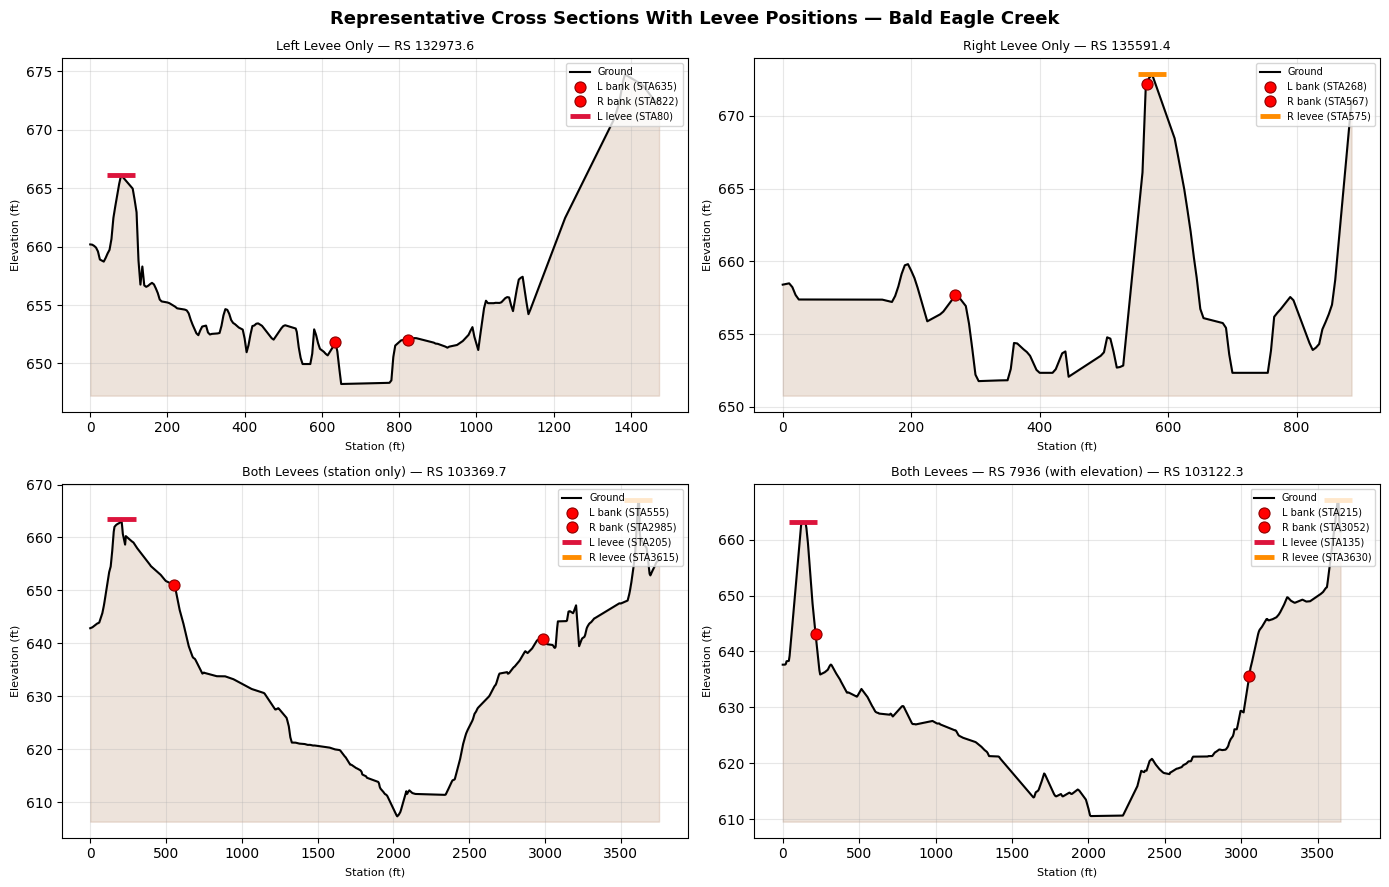

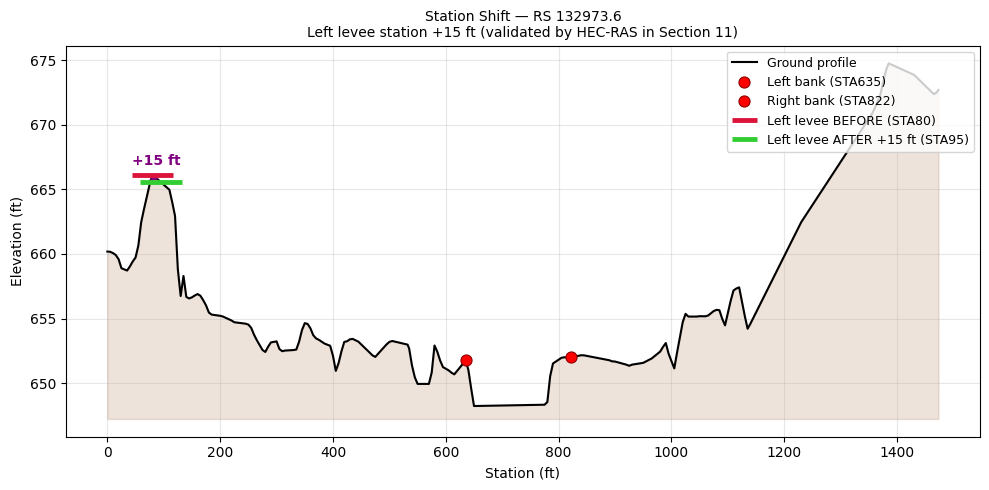

Station shift: Bald Eagle|Loc Hav|132973.6 | left 80.0 → 95.0 ft


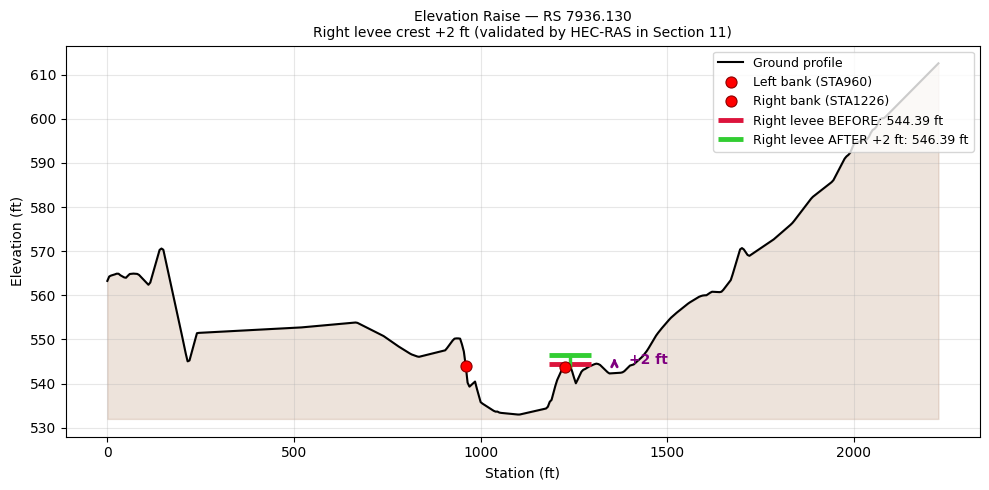

Elevation raise: Bald Eagle|Loc Hav|7936.130 | right crest 544.39 → 546.39 ft


In [11]:
import matplotlib.pyplot as plt

# ── Marker helpers ────────────────────────────────────────────────────────────

def _ground_elev(station, sta_arr, elev_arr):
    """Interpolate ground elevation at a station from the XS profile."""
    return float(np.interp(station, sta_arr, elev_arr))

def _bank_dot(ax, station, sta_arr, elev_arr, label=None, size=8):
    """Red dot at (station, ground elevation) — matches HEC-RAS GUI style."""
    y = _ground_elev(station, sta_arr, elev_arr)
    ax.plot(station, y, "o", color="red", markersize=size, zorder=6,
            markeredgecolor="darkred", markeredgewidth=0.8, label=label)

def _levee_bar(ax, station, elevation, sta_arr, elev_arr, color, lw=3.5,
               label=None, width_frac=0.025):
    """Blank elevation -> flat bar at ground. Explicit elevation -> T-shape (stem + cap)."""
    ground_y = _ground_elev(station, sta_arr, elev_arr)
    half_w = (sta_arr.max() - sta_arr.min()) * width_frac
    if np.isnan(elevation):
        # Blank-elevation levee: flat bar at ground (solver uses interpolated ground crest)
        ax.plot([station - half_w, station + half_w], [ground_y, ground_y],
                color=color, linewidth=lw, solid_capstyle="butt", zorder=5, label=label)
    else:
        # Explicit-elevation levee: T-shape showing embankment above terrain
        ax.plot([station, station], [ground_y, elevation],
                color=color, linewidth=lw * 0.7, zorder=5)
        ax.plot([station - half_w, station + half_w], [elevation, elevation],
                color=color, linewidth=lw, solid_capstyle="butt", zorder=5, label=label)

# ── Select representative cross sections ─────────────────────────────────────
xs_left_only  = active_levees[
    active_levees["left_station"].notna() & active_levees["right_station"].isna()
].iloc[0]
xs_right_only = active_levees[
    active_levees["right_station"].notna() & active_levees["left_station"].isna()
].iloc[0]
_both = active_levees[
    active_levees["left_station"].notna() & active_levees["right_station"].notna()
]
xs_both_1 = _both.iloc[0]
xs_both_2 = _both.iloc[1]  # RS 7936.130 — has actual right_elevation

modify_sta_row  = active_levees[active_levees["left_station"].notna()].iloc[0]
modify_elev_row = active_levees[active_levees["right_elevation"].notna()].iloc[0]

orig_left_sta   = modify_sta_row["left_station"]
new_left_sta    = orig_left_sta + 15.0
orig_right_elev = modify_elev_row["right_elevation"]
new_right_elev  = orig_right_elev + 2.0

# ── Figure 1: Four representative cross sections ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    "Representative Cross Sections With Levee Positions — Bald Eagle Creek",
    fontsize=13, fontweight="bold",
)

configs = [
    (xs_left_only,  "Left Levee Only"),
    (xs_right_only, "Right Levee Only"),
    (xs_both_1,     "Both Levees (station only)"),
    (xs_both_2,     "Both Levees — RS 7936 (with elevation)"),
]

for ax, (row, title) in zip(axes.flat, configs):
    try:
        se_df = GeomCrossSection.get_station_elevation(
            geom_file, row["River"], row["Reach"], str(row["RS"]))
        banks = GeomCrossSection.get_bank_stations(
            geom_file, row["River"], row["Reach"], str(row["RS"]))
        sta = se_df["Station"].values
        elev = se_df["Elevation"].values

        ax.fill_between(sta, elev.min() - 1, elev, alpha=0.15, color="saddlebrown")
        ax.plot(sta, elev, "k-", linewidth=1.5, label="Ground")

        if banks:
            lb, rb = banks
            _bank_dot(ax, lb, sta, elev, label=f"L bank (STA{lb:.0f})")
            _bank_dot(ax, rb, sta, elev, label=f"R bank (STA{rb:.0f})")

        if pd.notna(row["left_station"]):
            left_elev = row.get("left_elevation", np.nan)
            _levee_bar(ax, row["left_station"], left_elev, sta, elev,
                       color="crimson",
                       label=f"L levee (STA{row['left_station']:.0f}"
                             + (f", {left_elev:.1f} ft)" if pd.notna(left_elev) else ")"))
        if pd.notna(row["right_station"]):
            right_elev = row.get("right_elevation", np.nan)
            _levee_bar(ax, row["right_station"], right_elev, sta, elev,
                       color="darkorange",
                       label=f"R levee (STA{row['right_station']:.0f}"
                             + (f", {right_elev:.1f} ft)" if pd.notna(right_elev) else ")"))

        ax.set_title(f"{title} — RS {row['RS']}", fontsize=9)
        ax.set_xlabel("Station (ft)", fontsize=8)
        ax.set_ylabel("Elevation (ft)", fontsize=8)
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3)
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", transform=ax.transAxes, ha="center")

plt.tight_layout()
plt.show()

# ── Figure 2: Before/After — station shift (RS 132973.6) ─────────────────────
se_m  = GeomCrossSection.get_station_elevation(
    geom_file, modify_sta_row["River"], modify_sta_row["Reach"], str(modify_sta_row["RS"]))
banks_m = GeomCrossSection.get_bank_stations(
    geom_file, modify_sta_row["River"], modify_sta_row["Reach"], str(modify_sta_row["RS"]))
sta_m  = se_m["Station"].values
elev_m = se_m["Elevation"].values

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(sta_m, elev_m.min() - 1, elev_m, alpha=0.15, color="saddlebrown")
ax.plot(sta_m, elev_m, "k-", linewidth=1.5, label="Ground profile")

if banks_m:
    lb_m, rb_m = banks_m
    _bank_dot(ax, lb_m, sta_m, elev_m, label=f"Left bank (STA{lb_m:.0f})")
    _bank_dot(ax, rb_m, sta_m, elev_m, label=f"Right bank (STA{rb_m:.0f})")

_levee_bar(ax, orig_left_sta, np.nan, sta_m, elev_m, color="crimson",
           label=f"Left levee BEFORE (STA{orig_left_sta:.0f})")
_levee_bar(ax, new_left_sta,  np.nan, sta_m, elev_m, color="limegreen", lw=3.5,
           label=f"Left levee AFTER +15 ft (STA{new_left_sta:.0f})")

y_b = _ground_elev(orig_left_sta, sta_m, elev_m)
y_a = _ground_elev(new_left_sta,  sta_m, elev_m)
y_arrow = (y_b + y_a) / 2
ax.annotate("", xy=(new_left_sta, y_arrow), xytext=(orig_left_sta, y_arrow),
            arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax.text((orig_left_sta + new_left_sta) / 2,
        y_arrow + (elev_m.max() - elev_m.min()) * 0.04,
        "+15 ft", ha="center", color="purple", fontsize=10, fontweight="bold")

ax.set_title(f"Station Shift — RS {modify_sta_row['RS']}\n"
             "Left levee station +15 ft (validated by HEC-RAS in Section 11)", fontsize=10)
ax.set_xlabel("Station (ft)")
ax.set_ylabel("Elevation (ft)")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Station shift: {modify_sta_row['xs_id']} | left {orig_left_sta:.1f} → {new_left_sta:.1f} ft")

# ── Figure 3: Before/After — elevation change (RS 7936.130) ──────────────────
se_e  = GeomCrossSection.get_station_elevation(
    geom_file, modify_elev_row["River"], modify_elev_row["Reach"], str(modify_elev_row["RS"]))
banks_e = GeomCrossSection.get_bank_stations(
    geom_file, modify_elev_row["River"], modify_elev_row["Reach"], str(modify_elev_row["RS"]))
sta_e  = se_e["Station"].values
elev_e = se_e["Elevation"].values
r_sta  = modify_elev_row["right_station"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(sta_e, elev_e.min() - 1, elev_e, alpha=0.15, color="saddlebrown")
ax.plot(sta_e, elev_e, "k-", linewidth=1.5, label="Ground profile")

if banks_e:
    lb_e, rb_e = banks_e
    _bank_dot(ax, lb_e, sta_e, elev_e, label=f"Left bank (STA{lb_e:.0f})")
    _bank_dot(ax, rb_e, sta_e, elev_e, label=f"Right bank (STA{rb_e:.0f})")

_levee_bar(ax, r_sta, orig_right_elev, sta_e, elev_e, color="crimson",
           label=f"Right levee BEFORE: {orig_right_elev:.2f} ft")
_levee_bar(ax, r_sta, new_right_elev,  sta_e, elev_e, color="limegreen", lw=3.5,
           label=f"Right levee AFTER +2 ft: {new_right_elev:.2f} ft")

x_ann = r_sta + (sta_e.max() - r_sta) * 0.12
ax.annotate("", xy=(x_ann, new_right_elev), xytext=(x_ann, orig_right_elev),
            arrowprops=dict(arrowstyle="->", color="purple", lw=2))
ax.text(x_ann + (sta_e.max() - r_sta) * 0.04,
        (orig_right_elev + new_right_elev) / 2,
        "+2 ft", ha="left", va="center", color="purple", fontsize=10, fontweight="bold")

ax.set_title(f"Elevation Raise — RS {modify_elev_row['RS']}\n"
             "Right levee crest +2 ft (validated by HEC-RAS in Section 11)", fontsize=10)
ax.set_xlabel("Station (ft)")
ax.set_ylabel("Elevation (ft)")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Elevation raise: {modify_elev_row['xs_id']} | right crest {orig_right_elev:.2f} → {new_right_elev:.2f} ft")

In [12]:
if work_copy.exists():
    work_copy.unlink()
    print(f"Removed demo working copy: {work_copy.name}")
for bak in project_path.glob("BaldEagle_levee_test.g01.bak*"):
    bak.unlink()
    print(f"Removed backup: {bak.name}")
print("Demo working copy cleaned up before validation.")

Removed demo working copy: BaldEagle_levee_test.g01
Demo working copy cleaned up before validation.


## 11. Validate Write Format With HEC-RAS Compute

The round-trip assertions above confirm Python can read back what it wrote,
but the ultimate validation is running HEC-RAS on the **modified** geometry
and confirming the simulation completes without errors.

We extract a **fresh project copy**, apply two independent levee modifications, then run the unsteady simulation:
- **Station shift** — RS 132973.6 left station +15 ft
- **Elevation raise** — RS 7936.130 right crest elevation +2 ft (544.39 → 546.39 ft)

In [13]:
from ras_commander import init_ras_project, RasCmdr, HdfResultsPlan

logging.getLogger("ras_commander").setLevel(logging.INFO)

# Extract a FRESH project copy for compute validation
WORK_DIR = Path(os.environ.get(
    "RAS_COMMANDER_WORKDIR",
    project_path.parent / "levee_validation",
))
if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True, exist_ok=True)

fresh_project = RasExamples.extract_project("Balde Eagle Creek", output_path=WORK_DIR, suffix="validate")
fresh_geom = fresh_project / "BaldEagle.g01"
assert fresh_geom.exists()

# --------------------------------------------------------------------------
# Modification 1: Shift left levee station on RS 132973.6 (+15 ft).
# --------------------------------------------------------------------------
fresh_levees = GeomCrossSection.get_levees(fresh_geom)
active_fresh = fresh_levees[fresh_levees["left_station"].notna()].copy()

sta_xs_id = active_fresh["xs_id"].iloc[0]
orig_sta_levee = GeomCrossSection.get_levees(fresh_geom, xs_id=sta_xs_id)
orig_left_sta  = orig_sta_levee["left_station"].iloc[0]
new_left_sta   = orig_left_sta + 15.0

GeomCrossSection.set_levees(
    fresh_geom, xs_id=sta_xs_id,
    left_station=new_left_sta,
    create_backup=False,
)
v1 = GeomCrossSection.get_levees(fresh_geom, xs_id=sta_xs_id)
assert np.isclose(v1["left_station"].iloc[0], new_left_sta), "Station mismatch"
print(f"Mod 1 — Station shift: {sta_xs_id}")
print(f"  Left station: {orig_left_sta:.1f} → {new_left_sta:.1f} ft")

# --------------------------------------------------------------------------
# Modification 2: Raise right levee elevation on RS 7936.130 (+2 ft).
# --------------------------------------------------------------------------
elev_xs_id_val = "Bald Eagle|Loc Hav|7936.130"
orig_elev_val  = GeomCrossSection.get_levees(fresh_geom, xs_id=elev_xs_id_val)
orig_r_sta_val  = orig_elev_val["right_station"].iloc[0]
orig_r_elev_val = orig_elev_val["right_elevation"].iloc[0]
orig_l_sta_val  = orig_elev_val["left_station"].iloc[0]
new_r_elev_val  = orig_r_elev_val + 2.0

GeomCrossSection.set_levees(
    fresh_geom, xs_id=elev_xs_id_val,
    left_station=orig_l_sta_val,
    right_station=orig_r_sta_val,
    right_elevation=new_r_elev_val,
    create_backup=False,
)
v2 = GeomCrossSection.get_levees(fresh_geom, xs_id=elev_xs_id_val)
assert np.isclose(v2["right_elevation"].iloc[0], new_r_elev_val), "Elevation mismatch"
print(f"\nMod 2 — Elevation raise: {elev_xs_id_val}")
print(f"  Right crest: {orig_r_elev_val:.2f} → {v2['right_elevation'].iloc[0]:.2f} ft")

# --------------------------------------------------------------------------
# Run HEC-RAS on the MODIFIED geometry.
# --------------------------------------------------------------------------
ras_val = init_ras_project(fresh_project, "7.0")

plans_using_g01 = ras_val.plan_df[ras_val.plan_df["Geom File"] == "01"]
assert not plans_using_g01.empty, "No plan found using geometry file .g01"
plan_number = plans_using_g01.iloc[0]["plan_number"]

plan_file_path = Path(plans_using_g01.iloc[0]["full_path"])
plan_text = plan_file_path.read_text()
plan_text = re.sub(r"Program Version=.*", f"Program Version={ras_val.ras_version}", plan_text)
plan_file_path.write_text(plan_text)

geom_text = fresh_geom.read_text()
geom_text = re.sub(r"Program Version=.*", f"Program Version={ras_val.ras_version}", geom_text)
fresh_geom.write_text(geom_text)
print(f"\nUpdated Program Version to {ras_val.ras_version}")

print(f"Running Plan {plan_number} with 2 levee modifications...")
RasCmdr.compute_plan(plan_number, ras_object=ras_val, force_geompre=True, num_cores=4)

hdf_path = Path(ras_val.plan_df.loc[
    ras_val.plan_df["plan_number"] == plan_number, "HDF_Results_Path"
].iloc[0])
assert hdf_path.exists(), f"HDF file not created for plan {plan_number}"

messages = HdfResultsPlan.get_compute_messages(hdf_path)
lines = messages.splitlines() if messages else []
errors = [l for l in lines if "ERROR" in l.upper()
          and "VOLUME ACCOUNTING" not in l.upper()
          and "ITERATIONS" not in l.upper()
          and "WSEL ERROR" not in l.upper()]

if errors:
    print(f"ERRORS ({len(errors)}):")
    for e in errors[:10]:
        print(f"  {e}")
    raise RuntimeError(f"HEC-RAS reported {len(errors)} error(s) with modified geometry")

print(f"")
print(f"{'='*70}")
print(f"VALIDATION RESULT")
print(f"{'='*70}")
print(f"  Geometry file:    {fresh_geom.name} (MODIFIED)")
print(f"  Mod 1 (station):  {sta_xs_id} left station +15 ft")
print(f"  Mod 2 (elev):     {elev_xs_id_val} right crest +2 ft")
print(f"  HEC-RAS version:  {ras_val.ras_version}")
print(f"  Plan {plan_number}:          Preprocessing + simulation COMPLETED")
print(f"  Format errors:    {len(errors)}")
print(f"  HDF results:      {hdf_path.name}")
print(f"{'='*70}")
print(f"  set_levees station + elevation write format: VALIDATED")
print(f"{'='*70}")

2026-05-18 18:54:54 - ras_commander.RasExamples - INFO - Successfully extracted project 'Balde Eagle Creek' to G:\GH\ras-commander\working\notebook_runs\20260518_185328_217_levee\example_projects\levee_validation\Balde Eagle Creek_validate


2026-05-18 18:54:54 - ras_commander.geom.GeomCrossSection - INFO - Read levee data for 189 cross sections from G:\GH\ras-commander\working\notebook_runs\20260518_185328_217_levee\example_projects\levee_validation\Balde Eagle Creek_validate\BaldEagle.g01


2026-05-18 18:54:54 - ras_commander.geom.GeomCrossSection - INFO - Read levee data for 1 cross sections from G:\GH\ras-commander\working\notebook_runs\20260518_185328_217_levee\example_projects\levee_validation\Balde Eagle Creek_validate\BaldEagle.g01


2026-05-18 18:54:54 - ras_commander.geom.GeomParser - INFO - Successfully wrote geometry file: G:\GH\ras-commander\working\notebook_runs\20260518_185328_217_levee\example_projects\levee_validation\Balde Eagle Creek_validate\BaldEagle.g01


2026-05-18 18:54:54 - ras_commander.geom.GeomCrossSection - INFO - Updated levees for Bald Eagle/Loc Hav/RS 132973.6


...

2026-05-18 18:54:54 - ras_commander.RasCmdr - INFO - Running command: "C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe" -c "G:\GH\ras-commander\working\notebook_runs\20260518_185328_217_levee\example_projects\levee_validation\Balde Eagle Creek_validate\BaldEagle.prj" "G:\GH\ras-commander\working\notebook_runs\20260518_185328_217_levee\example_projects\levee_validation\Balde Eagle Creek_validate\BaldEagle.p01"



Updated Program Version to 7.0
Running Plan 01 with 2 levee modifications...


2026-05-18 18:56:56 - ras_commander.RasCmdr - INFO - HEC-RAS execution completed for plan: 01


2026-05-18 18:56:56 - ras_commander.RasCmdr - INFO - Total run time for plan 01: 121.95 seconds



VALIDATION RESULT
  Geometry file:    BaldEagle.g01 (MODIFIED)
  Mod 1 (station):  Bald Eagle|Loc Hav|132973.6 left station +15 ft
  Mod 2 (elev):     Bald Eagle|Loc Hav|7936.130 right crest +2 ft
  HEC-RAS version:  7.0
  Plan 01:          Preprocessing + simulation COMPLETED
  Format errors:    0
  HDF results:      BaldEagle.p01.hdf
  set_levees station + elevation write format: VALIDATED


## 12. Verify Results Extraction From HDF

The compute validation above proves HEC-RAS accepted the modified levee
geometry. Extract cross-section water surface results from the HDF output
to confirm the simulation produced valid hydraulic data at cross sections
with levees.

In [14]:
from ras_commander.hdf import HdfResultsXsec

xsec_ts = HdfResultsXsec.get_xsec_timeseries(hdf_path)
print(f"Cross-section time series dataset:")
print(f"  Variables: {list(xsec_ts.data_vars)}")
print(f"  Dimensions: {dict(xsec_ts.dims)}")
print(f"  Cross sections: {xsec_ts.dims.get('cross_section', 'N/A')}")
print(f"  Time steps: {xsec_ts.dims.get('time', 'N/A')}")

# Locate the station-modified cross section (Modification 1)
parts = sta_xs_id.split("|")
modified_rs = parts[2] if len(parts) == 3 else sta_xs_id

stations = xsec_ts.coords["Station"].values
rs_float = float(modified_rs)
station_matches = [i for i, s in enumerate(stations) if abs(float(s) - rs_float) < 1.0]

if station_matches:
    xs_idx = station_matches[0]
    ws = xsec_ts["Water_Surface"][:, xs_idx].values
    max_ws = float(xsec_ts["Maximum_Water_Surface"].values[xs_idx])
    max_flow = float(xsec_ts["Maximum_Flow"].values[xs_idx])

    print(f"")
    print(f"Results at station-modified cross section (RS {modified_rs}):")
    print(f"  Max water surface:  {max_ws:.2f} ft")
    fmt = f"{max_flow:,.1f}"
    print(f"  Max flow:           {fmt} cfs")
    print(f"  Time steps:         {len(ws)}")
    print(f"  WS range:           {np.nanmin(ws):.2f} -- {np.nanmax(ws):.2f} ft")

    assert not np.all(np.isnan(ws)), "All water surface values are NaN"
    assert max_flow > 0, "No flow at modified cross section"
else:
    print(f"Cross section RS {modified_rs} not found in time series output.")
    print(f"Available stations (first 10): {stations[:10]}")

# Also locate the elevation-modified cross section (Modification 2)
elev_parts = elev_xs_id_val.split("|")
elev_rs = elev_parts[2] if len(elev_parts) == 3 else elev_xs_id_val
elev_rs_float = float(elev_rs)
elev_matches = [i for i, s in enumerate(stations) if abs(float(s) - elev_rs_float) < 1.0]

if elev_matches:
    e_idx = elev_matches[0]
    max_ws_e = float(xsec_ts["Maximum_Water_Surface"].values[e_idx])
    max_flow_e = float(xsec_ts["Maximum_Flow"].values[e_idx])
    print(f"")
    print(f"Results at elevation-modified cross section (RS {elev_rs}):")
    print(f"  Max water surface:  {max_ws_e:.2f} ft")
    fmt_e = f"{max_flow_e:,.1f}"
    print(f"  Max flow:           {fmt_e} cfs")

# Summary across all cross sections
peak_ws = xsec_ts["Maximum_Water_Surface"].values
peak_flow = xsec_ts["Maximum_Flow"].values
xs_summary = pd.DataFrame({
    "Station": stations,
    "Max WS (ft)": np.round(peak_ws, 2),
    "Max Flow (cfs)": np.round(peak_flow, 1),
})
print(f"")
print(f"Peak values across all {len(xs_summary)} cross sections:")
display(xs_summary.describe().round(2))

print(f"")
print(f"{'='*70}")
print(f"RESULTS EXTRACTION VALIDATED")
print(f"  Cross sections with data: {len(xs_summary)}")
print(f"  Global max water surface: {np.nanmax(peak_ws):.2f} ft")
fmt2 = f"{np.nanmax(peak_flow):,.1f}"
print(f"  Global max flow:          {fmt2} cfs")
print(f"{'='*70}")

Cross-section time series dataset:
  Variables: ['Water_Surface', 'Velocity_Total', 'Velocity_Channel', 'Flow_Lateral', 'Flow']
  Dimensions: {'time': 150, 'cross_section': 178}
  Cross sections: 178
  Time steps: 150

Results at station-modified cross section (RS 132973.6):
  Max water surface:  663.44 ft
  Max flow:           49,986.5 cfs
  Time steps:         150
  WS range:           651.27 -- 663.44 ft

Results at elevation-modified cross section (RS 7936.130):
  Max water surface:  561.99 ft
  Max flow:           25,500.3 cfs

Peak values across all 178 cross sections:


,Max WS (ft),Max Flow (cfs)
count,178.00,178.00
mean,611.27,34672.23
std,45.32,8576.51
min,561.38,25433.00
25%,566.65,30146.87
50%,590.02,31068.20
75%,661.76,43004.75
max,672.81,50000.00



RESULTS EXTRACTION VALIDATED
  Cross sections with data: 178
  Global max water surface: 672.81 ft
  Global max flow:          50,000.0 cfs


## Summary

This notebook demonstrated the full `get_levees()` / `set_levees()` API:

- **`get_levees()`** — Read levee data as a DataFrame with `xs_id`, `River`, `Reach`, `RS`, `left_station`, `left_elevation`, `right_station`, `right_elevation`
- **`set_levees()`** — Write station and/or elevation for either levee side; omit a side to deactivate it
- **Station shift** — Move a levee station outward or inward (Section 5a)
- **Elevation raise** — Increase a levee crest elevation; HEC-RAS uses this as the overtopping threshold (Section 5b)
- **Elevation lower** — Decrease a levee crest elevation to simulate a reduced protection scenario (Section 5c)
- **Insert** — Add a `Levee=` line to a cross section that has none, with full station + elevation (Section 6)
- **Remove** — Deactivate one side while preserving the other (Section 7)
- **Filtering** — Query by `xs_id` or `river`/`reach`/`rs` parameters (Sections 4, 8)
- **Batch analysis** — DataFrame output enables bulk statistics across the full geometry (Section 9)
- **Visualization** — XS profiles with vertical station markers and horizontal elevation lines; before/after comparison for both station and elevation changes (Section 10)
- **HEC-RAS compute validation** — Station shift + elevation raise both accepted by the unsteady preprocessor and solver (Section 11)
- **HDF results extraction** — Cross-section water surface and flow time series confirmed from simulation output (Section 12)

### Levee Data Format

```
Levee=left_flag,left_station,left_elevation,right_flag,right_station,right_elevation,0,0
```
- Flag `-1` = active side; `0` = inactive
- **Blank elevation** (NaN / empty field): HEC-RAS interpolates the ground profile at the levee station and uses that as the overtopping threshold; RASMapper does not write an HDF Levees dataset and flood polygon clipping is inactive
- **Explicit elevation**: HEC-RAS uses the defined crest value; RASMapper writes the HDF Levees dataset and activates flood polygon clipping at that boundary
- Never write `0.0` when you mean blank -- zero is treated as an explicit 0 ft crest elevation

### Example Project

Bald Eagle Creek (1D Unsteady Flow Hydraulics) — 189 cross sections, 41 with active levees, 1 with a defined crest elevation (RS 7936.130, right elev = 544.39 ft).